# Ανάλυση Επιβίωσης Χρόνου-έως-Εγκατάλειψη μιας Κοόρτης Φοιτητών

## Συνοπτική Παρουσίαση

**Πλαίσιο.** Ένα γραφείο θεσμικής έρευνας σε ένα τετραετές κολέγιο θέλει να κατανοήσει *πότε*, και όχι απλώς *αν*, οι φοιτητές αποχωρούν. Μια πρωτοετής κοόρτη παρακολουθείται εξάμηνο προς εξάμηνο από την εγγραφή· κάποιοι αποφοιτούν, κάποιοι εγκαταλείπουν, και μερικοί είναι ακόμη εγγεγραμμένοι όταν κλείνει το παράθυρο παρατήρησης. Επειδή το αποτέλεσμα για τους ακόμη εγγεγραμμένους φοιτητές είναι άγνωστο (δεξιά λογοκριμένο), και επειδή η αποφοίτηση αφαιρεί έναν φοιτητή από τη δεξαμενή κινδύνου χωρίς να αποτελεί εγκατάλειψη, η συνηθισμένη παλινδρόμηση επιτυχίας/αποτυχίας απορρίπτει την πληροφορία χρονισμού και προκαλεί μεροληψία σε κάθε εκτίμηση που αγνοεί τη λογοκρισία. Το σωστό εργαλείο είναι η **ανάλυση χρόνου-έως-συμβάν (επιβίωσης)**, όπου το συμβάν ενδιαφέροντος είναι η **εγκατάλειψη** και το ρολόι μετριέται σε ακαδημαϊκά εξάμηνα εγγραφής.

**Επιχειρησιακό ερώτημα.** Διαχωρίζει η **ακαδημαϊκή κατάσταση πρώτου εξαμήνου** ενός φοιτητή (μια σημαία έγκαιρης προειδοποίησης) τις τροχιές χρονισμού εγκατάλειψης της κοόρτης, και ποια χαρακτηριστικά των φοιτητών οδηγούν τον κίνδυνο εγκατάλειψης μετά την προσαρμογή; Οι απαντήσεις τροφοδοτούν ένα σύστημα έγκαιρης προειδοποίησης: οι φοιτητές των οποίων ο εκτιμώμενος κίνδυνος εγκατάλειψης είναι υψηλός θα πρέπει να λαμβάνουν συμβουλευτική προσέγγιση στα πρώτα τους εξάμηνα, όταν η παρέμβαση είναι φθηνότερη και πιο αποτελεσματική.

**Προσέγγιση.** Προσομοιώνουμε μια κοόρτη 100 φοιτητών ενσωματωμένα (χωρίς εξωτερικά δεδομένα), και στη συνέχεια εργαζόμαστε μέσα από μια τυπική ροή εργασίας επιβίωσης:

1. Η **PROC MEANS** σκιαγραφεί τους προβλέπτες στα τρία παρατηρούμενα αποτελέσματα (Αποφοίτησε / Εγκατέλειψε / ακόμη Εγγεγραμμένος) για να επιβεβαιώσει ότι το προσομοιωμένο σήμα συμπεριφέρεται λογικά.
2. Η **PROC FREQ** διασταυρώνει την ακαδημαϊκή κατάσταση πρώτου εξαμήνου με το αποτέλεσμα, με έλεγχο συσχέτισης χι-τετράγωνο.
3. Η **PROC UNIVARIATE** αναφέρει εύρωστα εκατοστημόρια του χρόνου-έως-εγκατάλειψη ανά κατάσταση.
4. Η **PROC LIFETEST** εκτιμά καμπύλες εγκατάλειψης Kaplan-Meier διαστρωματωμένες κατά κατάσταση και εκτελεί ελέγχους ισότητας **log-rank** και **Wilcoxon**.
5. Η **PROC PHREG** προσαρμόζει ένα πολυμεταβλητό μοντέλο **αναλογικών κινδύνων Cox** για τον κίνδυνο εγκατάλειψης, με μια επίδραση `CLASS` κωδικοποιημένη ως προς αναφορά, χειρισμό ισοπαλιών Efron, και διαστήματα εμπιστοσύνης ορίων κινδύνου.

**Τι δείχνουν τα δεδομένα.** Από τους 100 προσομοιωμένους φοιτητές, **49 εγκατέλειψαν, 49 αποφοίτησαν, και 2 παρέμειναν εγγεγραμμένοι** στην αποκοπή των 12 εξαμήνων. Οι φοιτητές που επισημάνθηκαν με **ακαδημαϊκή προειδοποίηση** στο πρώτο τους εξάμηνο (GPA πρώτου εξαμήνου κάτω από 2.5) εγκαταλείπουν πολύ ταχύτερα από τους φοιτητές σε καλή κατάσταση: διάμεσος χρόνος-έως-εγκατάλειψη **3.8 εξάμηνα έναντι 8.7 εξάμηνα**, έναν διαχωρισμό που ο έλεγχος log-rank επιβεβαιώνει (χι-τετράγωνο = 10.73, *p* = 0.0011). Το μοντέλο Cox αναγνωρίζει το GPA πρώτου εξαμήνου (λόγος κινδύνου 0.21 ανά μονάδα GPA, *p* < 0.0001), το GPA λυκείου (HR 0.45, *p* = 0.027), και την κατάσταση πρώτης γενιάς (HR 2.03, *p* = 0.031) ως σημαντικούς προσαρμοσμένους παράγοντες εγκατάλειψης, ενώ η κατάσταση υποτροφίας Pell δεν είναι σημαντική όταν ελέγχεται το GPA (HR 0.95, *p* = 0.85).

> *Όλα τα στοιχεία είναι ενδεικτικά και παράγονται από συνθετικά δεδομένα· δεν αποτελούν πραγματικά αρχεία φοιτητών. Αυτό το περιβάλλον εκτελείται χωρίς άδεια, οπότε η κοόρτη έχει μέγεθος 100 φοιτητών.*

## Πηγές Δεδομένων

Όλα τα δεδομένα είναι **συνθετικά**, παραγόμενα ενσωματωμένα στο πρώτο βήμα DATA με `CALL STREAMINIT(20260611)` και τη συνάρτηση `RAND`. Χωρίς εξωτερικά αρχεία ή πρόσβαση δικτύου. Μία γραμμή ανά προσομοιωμένο φοιτητή.

**Σύνολο δεδομένων `εγγραφες`** (100 γραμμές, μία γραμμή ανά φοιτητή)

| Μεταβλητή | Τύπος | Περιγραφή | Παραγωγική κατανομή |
|----------|------|-------------|--------------------------|
| `αναγν_φοιτητη` | Num | Μοναδικό κλειδί φοιτητή | ακολουθία 1–100 |
| `πρωτη_γενια` / `ετικετα_γενιας` | Num / Char | Σημαία πρώτης γενιάς (0/1) και ετικέτα | Bernoulli, ~42% |
| `pell` | Num | Σημαία υποτροφίας Pell (οικονομικής ανάγκης) (0/1) | Bernoulli, ~42% |
| `προγραμμα` | Char | ΘΕΤ / ΟΙΚ / ΑΝΘ | κατηγορική (~42% / 32% / 26%) |
| `gpa_λυκειου` | Num | GPA λυκείου (1.8–4.0) | Normal(3.00, 0.42), περιορισμένη |
| `gpa_α_εξαμηνου` | Num | GPA πρώτου εξαμήνου κολεγίου (0–4.0) | f(gpa_λυκειου, προγραμμα) + κανονικός θόρυβος |
| `κατασταση` | Char | Ακαδημαϊκή κατάσταση πρώτου εξαμήνου | `gpa_α_εξαμηνου < 2.5` → Ακαδημαϊκή προειδοποίηση, αλλιώς Καλή κατάσταση |
| `χρονος_εξαμηνα` | Num | Εξάμηνα εγγραφής έως συμβάν ή λογοκρισία | ανταγωνιστικές κληρώσεις Weibull· περιορισμένο στο 12 |
| `εγκατελειψε` | Num | Δείκτης συμβάντος εγκατάλειψης (1 = εγκατέλειψε, 0 = λογοκριμένο) | παράγωγο |
| `εκβαση` | Char | Αποφοίτησε / Εγκατέλειψε / Εγγεγραμμένος | παράγωγο από ανταγωνιστικές κληρώσεις |

Ένας λανθάνων γραμμικός προβλέπτης στη λογαριθμική κλίμακα συνδέει τον **ρυθμό εγκατάλειψης** κάθε φοιτητή με το GPA πρώτου εξαμήνου, το GPA λυκείου, την κατάσταση πρώτης γενιάς, και την οικονομική ανάγκη, ώστε οι προβλέπτες να φέρουν γνήσιο αλλά θορυβώδες σήμα. Η εγκατάλειψη και η αποφοίτηση κληρώνονται ως **ανταγωνιστικοί** λανθάνοντες χρόνοι (Weibull)· όποιος συμβεί πρώτος μέσα σε παράθυρο 12 εξαμήνων γίνεται το παρατηρούμενο αποτέλεσμα, και οι φοιτητές που φτάνουν στο εξάμηνο 12 χωρίς κανένα από τα δύο είναι δεξιά λογοκριμένοι. Για τα μοντέλα επιβίωσης το **συμβάν είναι η εγκατάλειψη** (`εγκατελειψε = 1`)· η αποφοίτηση και η συνεχιζόμενη εγγραφή αντιμετωπίζονται και οι δύο ως λογοκρισία (`εγκατελειψε = 0`).

## 1. Προσομοίωση της κοόρτης φοιτητών

Το πρώτο κελί κατασκευάζει μια συνθετική κοόρτη 100 φοιτητών. Ένας λανθάνων γραμμικός προβλέπτης στη λογαριθμική κλίμακα συνδέει τον ρυθμό εγκατάλειψης κάθε φοιτητή με το GPA πρώτου εξαμήνου, το GPA λυκείου, την κατάσταση πρώτης γενιάς, και την κατάσταση Pell. Η εγκατάλειψη και η αποφοίτηση παράγονται ως **ανταγωνιστικοί** λανθάνοντες χρόνοι (κληρώσεις Weibull)· όποιος συμβεί πρώτος μέσα σε παράθυρο παρατήρησης 12 εξαμήνων γίνεται το παρατηρούμενο αποτέλεσμα, και οι φοιτητές που φτάνουν στο εξάμηνο 12 χωρίς να εγκαταλείψουν ή να αποφοιτήσουν είναι δεξιά λογοκριμένοι. Ένα GPA πρώτου εξαμήνου κάτω από 2.5 επισημαίνει τον φοιτητή για **ακαδημαϊκή προειδοποίηση** — το σήμα έγκαιρης προειδοποίησης που ελέγχουμε στο βήμα επιβίωσης. Οι τυχαίες κληρώσεις χρησιμοποιούν `CALL STREAMINIT` για αναπαραγωγιμότητα και τη συνάρτηση `RAND` στις κατανομές Uniform, Normal, και Weibull. Σκληρά κατώφλια και περιορισμοί διατηρούν κάθε τιμή εύλογη (GPA στο 0–4.0).

In [1]:
ΔΕΔΟΜΕΝΑ εγγραφες;
    CALL streaminit(20260611);
    LENGTH κατασταση $48 ετικετα_γενιας $48 προγραμμα $8 εκβαση $28;
    ΕΤΙΚΕΤΑ αναγν_φοιτητη   = "Αναγνωριστικό φοιτητή"
          πρωτη_γενια     = "Πρώτης γενιάς (δείκτης)"
          ετικετα_γενιας  = "Κατηγορία γενιάς"
          pell            = "Λήπτης υποτροφίας Pell"
          προγραμμα       = "Πρόγραμμα σπουδών"
          gpa_λυκειου     = "ΜΟ λυκείου"
          gpa_α_εξαμηνου  = "ΜΟ πρώτου εξαμήνου"
          κατασταση       = "Ακαδημαϊκή κατάσταση"
          χρονος_εξαμηνα  = "Χρόνος έως συμβάν (εξάμηνα)"
          εγκατελειψε     = "Εγκατέλειψε (συμβάν)"
          εκβαση          = "Παρατηρούμενη έκβαση";
    ΕΠΑΝΑΛΗΨΗ αναγν_φοιτητη = 1 ΕΩΣ 100;
        /* Δείκτες πρώτης γενιάς και οικονομικής ανάγκης */
        πρωτη_γενια = (rand("uniform") < 0.42);
        ΕΑΝ πρωτη_γενια ΤΟΤΕ ετικετα_γενιας = "Πρώτης γενιάς";
        ΑΛΛΙΩΣ              ετικετα_γενιας = "Συνεχιζόμενης γενιάς";
        pell = (rand("uniform") < 0.42);

        /* Πρόγραμμα σπουδών */
        v = rand("uniform");
        ΕΑΝ      v < 0.42 ΤΟΤΕ προγραμμα = "ΘΕΤ";
        ΑΛΛΙΩΣ ΕΑΝ v < 0.74 ΤΟΤΕ προγραμμα = "ΟΙΚ";
        ΑΛΛΙΩΣ                  προγραμμα = "ΑΝΘ";

        /* Ακαδημαϊκή προετοιμασία και επίδοση πρώτου εξαμήνου */
        gpa_λυκειου = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        gpa_α_εξαμηνου = round(MIN(4.0, MAX(0.0,
                     0.55*gpa_λυκειου + 1.05 + 0.12*(προγραμμα="ΘΕΤ")
                     + rand("normal", 0, 0.42))), 0.01);

        /* Δείκτης έγκαιρης ειδοποίησης: ΜΟ πρώτου εξαμήνου κάτω από 2.5 = ακαδημαϊκή προειδοποίηση */
        ΕΑΝ gpa_α_εξαμηνου < 2.5 ΤΟΤΕ κατασταση = "Ακαδημαϊκή προειδοποίηση";
        ΑΛΛΙΩΣ                    κατασταση = "Καλή κατάσταση";

        /* Λανθάνων κίνδυνος εγκατάλειψης σε λογαριθμική κλίμακα: χαμηλότερος ΜΟ,
           πρώτη γενιά και υποτροφία Pell αυξάνουν τον ρυθμό εγκατάλειψης. */
        eta = -1.05
             - 1.45*(gpa_α_εξαμηνου - 2.8)
             - 0.55*(gpa_λυκειου - 3.0)
             + 1.05*πρωτη_γενια
             + 0.45*pell;
        drop_rate = EXP(eta);

        /* Ανταγωνιστικοί λανθάνοντες χρόνοι (εξάμηνα): εγκατάλειψη vs αποφοίτηση */
        t_drop = rand("weibull", 1.2, 7.0) / MAX(0.30, drop_rate);
        t_grad = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(gpa_α_εξαμηνου - 2.8));

        /* Παράθυρο διοικητικής λογοκρισίας 12 εξαμήνων */
        censor_at = 12;
        ΕΑΝ t_drop <= t_grad AND t_drop <= censor_at ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            εκβαση = "Εγκατέλειψε";   εγκατελειψε = 1; χρονος_εξαμηνα = t_drop;
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΑΝ t_grad < t_drop AND t_grad <= censor_at ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            εκβαση = "Αποφοίτησε"; εγκατελειψε = 0; χρονος_εξαμηνα = t_grad;
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ;
            εκβαση = "Εγγεγραμμένος";  εγκατελειψε = 0; χρονος_εξαμηνα = censor_at;
        ΤΕΛΟΣ;
        χρονος_εξαμηνα = round(χρονος_εξαμηνα, 0.1);
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΚΡΑΤΗΣΗ αναγν_φοιτητη πρωτη_γενια ετικετα_γενιας pell προγραμμα gpa_λυκειου
         gpa_α_εξαμηνου κατασταση χρονος_εξαμηνα εγκατελειψε εκβαση;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA εγγραφες


NOTE: Wrote εγγραφες (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Σκιαγράφηση προβλεπτών ανά παρατηρούμενο αποτέλεσμα

Πριν από τη μοντελοποίηση, επιβεβαιώνουμε ότι οι προσομοιωμένοι προβλέπτες κινούνται στις αναμενόμενες κατευθύνσεις. Η **PROC MEANS** αναφέρει το πλήθος, τον μέσο, τη διασπορά, και το εύρος κάθε αριθμητικού προβλέπτη εντός των τριών παρατηρούμενων αποτελεσμάτων.

Η κοόρτη διαχωρίζεται σε **49 Αποφοίτησαν / 49 Εγκατέλειψαν / 2 ακόμη Εγγεγραμμένους**. Οι απόφοιτοι φέρουν υψηλότερο GPA πρώτου εξαμήνου (μέσος **2.94** έναντι **2.54** για τους φοιτητές που εγκατέλειψαν) και υψηλότερο GPA λυκείου (**3.10** έναντι **2.90**) — ακριβώς η βαθμίδα ακαδημαϊκής προετοιμασίας που αναμένει η ανάλυση. Οι δύο ακόμη εγγεγραμμένοι φοιτητές βρίσκονται ακριβώς στην οροφή λογοκρισίας των 12 εξαμήνων στο `χρονος_εξαμηνα` (μέσος 12.00, τυπική απόκλιση 0), τη δεξιά λογοκρισία που μια ανάλυση φθοράς οφείλει να σεβαστεί. Μεταξύ των φοιτητών που εγκατέλειψαν, το συμβάν φτάνει νωρίς: μέσος **3.31 εξάμηνα**, με εύρος από 0.1 έως 8.9.

In [2]:
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=εγγραφες n mean std MIN MAX maxdec=2;
    ΚΛΑΣΗ εκβαση;
    ΜΕΤΑΒΛΗΤΗ gpa_λυκειου gpa_α_εξαμηνου χρονος_εξαμηνα;
ΕΚΤΕΛΕΣΗ;

                                                  The MEANS Procedure

                               Analysis Variable : gpa_λυκειου ΜΟ λυκείου

        Παρατηρούμενη έκβαση                             N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------------------------------
        Αποφοίτησε                                          49           3.10           0.46           1.97           4.00
        Εγγεγραμμένος                                        2           3.10           0.17           2.98           3.22
        Εγκατέλειψε                                         49           2.90           0.45           2.01           3.89
        ------------------------------------------------------------------------------------------------------------------

                     Analysis Variable : gpa_α_εξαμηνου ΜΟ πρώτου εξαμήνου

        Παρατηρούμενη έκβαση           


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Παρακολουθεί η σημαία έγκαιρης προειδοποίησης το αποτέλεσμα;

Το σύστημα έγκαιρης προειδοποίησης επισημαίνει κάθε φοιτητή του οποίου το GPA πρώτου εξαμήνου πέφτει κάτω από 2.5 για **ακαδημαϊκή προειδοποίηση**. Η **PROC FREQ** διασταυρώνει αυτή τη σημαία με το παρατηρούμενο αποτέλεσμα και εκτελεί έναν έλεγχο συσχέτισης χι-τετράγωνο. Καταστέλλουμε τα ποσοστά γραμμής, στήλης, και συνόλου (`NOROW NOCOL NOPERCENT`) ώστε ο πίνακας να δείχνει τα ακατέργαστα πλήθη, και προσθέτουμε μονόδρομες συχνότητες του `κατασταση` και της κατάστασης πρώτης γενιάς για τη σύνθεση της κοόρτης.

Η διασταύρωση είναι έντονη: από τους **29** φοιτητές που επισημάνθηκαν για ακαδημαϊκή προειδοποίηση, **21 εγκατέλειψαν** και μόνο 8 αποφοίτησαν· από τους **71** σε καλή κατάσταση, **41 αποφοίτησαν** και 28 εγκατέλειψαν. Η συσχέτιση είναι σημαντική (χι-τετράγωνο = 9.21, df = 2, *p* = 0.0100· V του Cramer = 0.30). Σημειώστε την **προειδοποίηση που εκτυπώνεται μαζί της**: με 100 φοιτητές και μια ισχνή στήλη "Εγγεγραμμένος" με δύο απόφοιτους, το ένα τρίτο των κελιών του πίνακα έχει αναμενόμενα πλήθη κάτω από 5, οπότε η τιμή *p* του χι-τετράγωνο είναι εύθραυστη εδώ. Αυτή η ευθραυστότητα είναι ακριβώς ο λόγος που οι έλεγχοι επιβίωσης στις επόμενες ενότητες — που χρησιμοποιούν την πλήρη πληροφορία χρονισμού αντί για έναν πίνακα 3×2 — είναι ο πιο αξιόπιστος έλεγχος της επίδρασης της κατάστασης.

                                                   The FREQ Procedure

Table of Ακαδημαϊκή κατάσταση by Παρατηρούμενη έκβαση

Ακαδημαϊκή κατάσταση                            |                Αποφοίτησε |             Εγγεγραμμένος |               Εγκατέλειψε |                      Total
------------------------------------------------+---------------------------+---------------------------+---------------------------+---------------------------
Ακαδημαϊκή προειδοποίηση                        |                         8 |                         0 |                        21 |                         29
------------------------------------------------+---------------------------+---------------------------+---------------------------+---------------------------
Καλή κατάσταση                                  |                        41 |                         2 |                        28 |                         71
------------------------------------------------+--------------------


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_κατασταση_εκβαση.spec.json
NOTE: ODS plot written: freq_κατασταση.spec.json
NOTE: ODS plot written: freq_ετικετα_γενιας.spec.json
NOTE: PROC FREQ statement used.


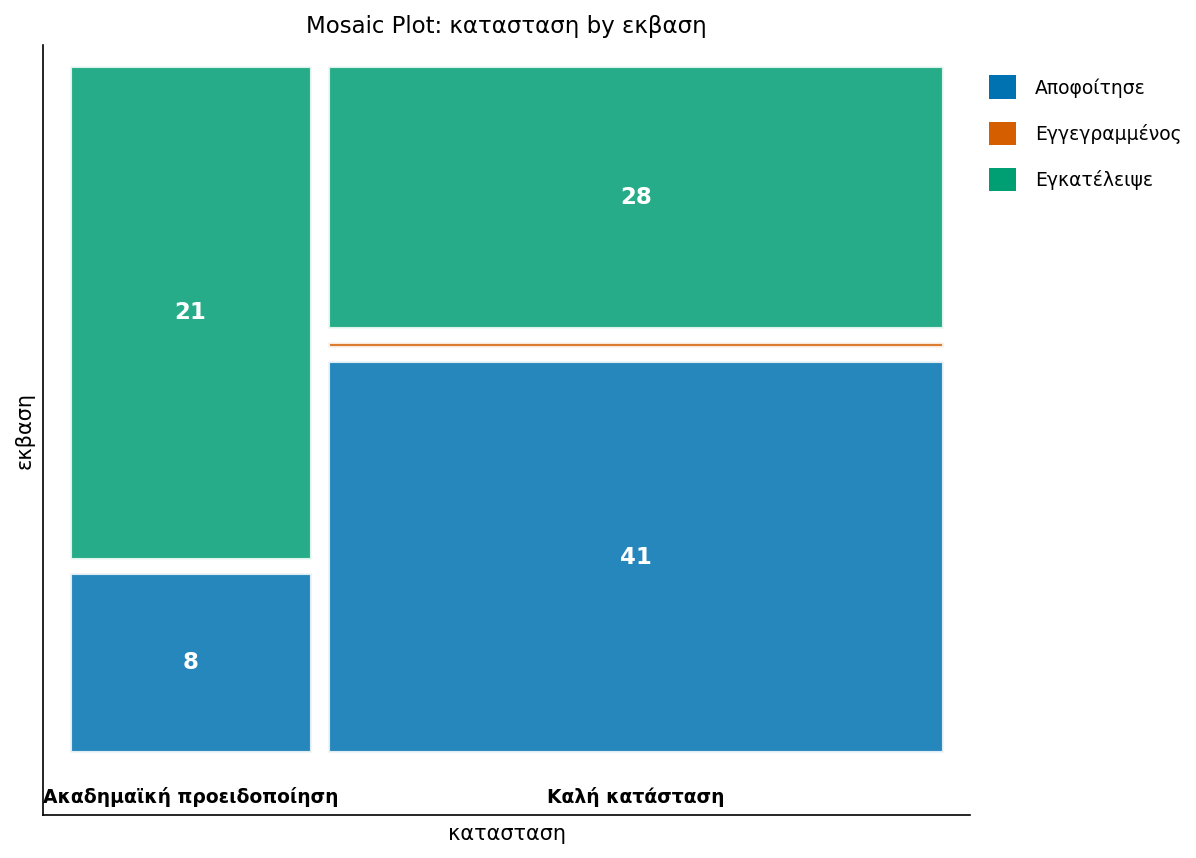

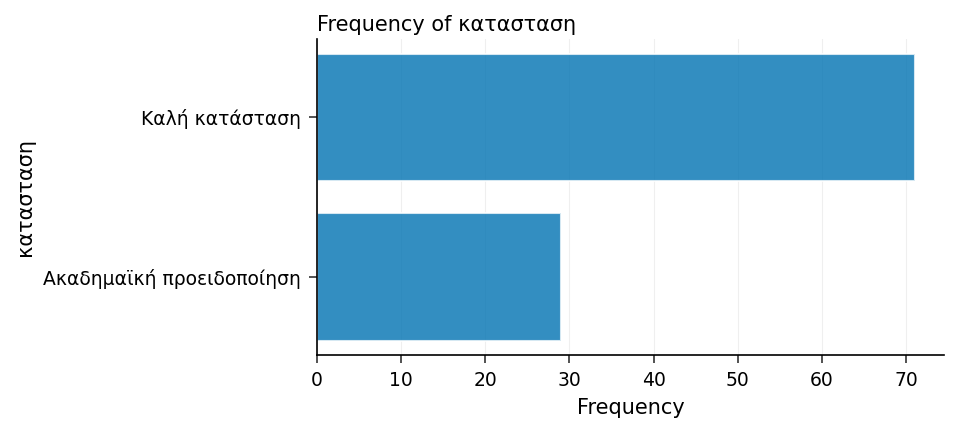

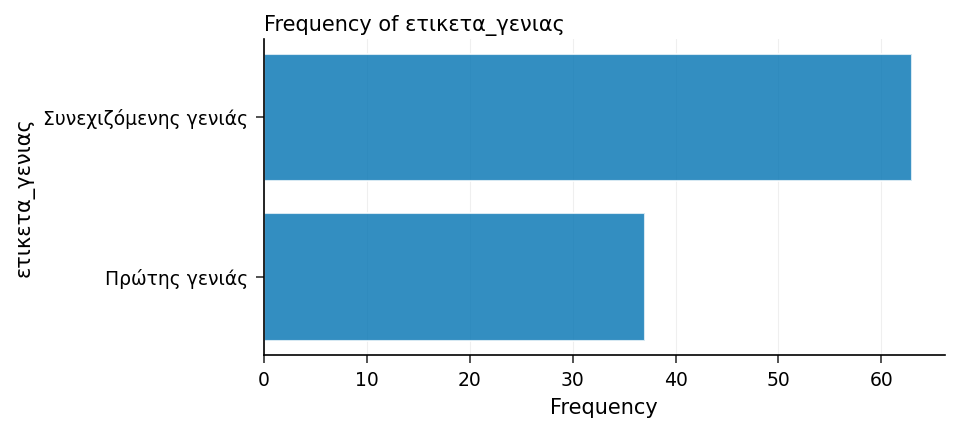

In [3]:
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=εγγραφες;
    TABLES κατασταση*εκβαση / chisq norow nocol nopercent;
    TABLES κατασταση ετικετα_γενιας;
ΕΚΤΕΛΕΣΗ;

## 4. Πότε συμβαίνουν οι εγκαταλείψεις; Εκατοστημόρια ανά κατάσταση

Για τους φοιτητές που πράγματι εγκατέλειψαν, *πότε* αποχώρησαν; Η **PROC UNIVARIATE** (περιορισμένη σε `εγκατελειψε = 1`) αναφέρει το 10ο, 50ό (διάμεσος), και 90ό εκατοστημόριο του χρόνου-έως-εγκατάλειψη εντός κάθε ομάδας κατάστασης, γραμμένα σε ένα σύνολο δεδομένων εξόδου που έπειτα εκτυπώνουμε. Αυτό περιγράφει τη διασπορά του χρονισμού εγκατάλειψης χωρίς να υποθέτει κατανομή.

Η διάμεσος εγκατάλειψη μεταξύ των φοιτητών που αποχώρησαν συμβαίνει γύρω στο εξάμηνο **2.4** (ακαδημαϊκή προειδοποίηση) έναντι **2.6** (καλή κατάσταση) — κοντά, επειδή *υπό την προϋπόθεση εγκατάλειψης*, και οι δύο ομάδες τείνουν να αποχωρούν νωρίς. Η επίδραση της κατάστασης δεν αφορά επομένως κυρίως το *πότε* συμβαίνει μια εγκατάλειψη αλλά το *πόσοι* φοιτητές εγκαταλείπουν και πόσο γρήγορα αραιώνει η δεξαμενή κινδύνου, κάτι που ακριβώς αποτυπώνουν οι καμπύλες Kaplan-Meier στην επόμενη ενότητα.

In [4]:
ΔΙΑΔΙΚΑΣΙΑ UNIVARIATE ΔΕΔΟΜΕΝΑ=εγγραφες NOPRINT;
    ΟΠΟΥ εγκατελειψε = 1;
    ΚΛΑΣΗ κατασταση;
    ΜΕΤΑΒΛΗΤΗ χρονος_εξαμηνα;
    ΕΞΟΔΟΣ out=αναφορα_εγκαταλειψης pctlpts=10 50 90 pctlpre=τ_ p=;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=αναφορα_εγκαταλειψης noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ κατασταση = "Ακαδημαϊκή κατάσταση"
          τ_10 = "10ο εκατοστημόριο"
          τ_50 = "Διάμεσος (50ό)"
          τ_90 = "90ό εκατοστημόριο";
    TITLE "Εκατοστημόρια χρόνου έως εγκατάλειψη (εξάμηνα), ανά ακαδημαϊκή κατάσταση";
ΕΚΤΕΛΕΣΗ;
TITLE;

                        Εκατοστημόρια χρόνου έως εγκατάλειψη (εξάμηνα), ανά ακαδημαϊκή κατάσταση                        

                                      ΚΑΤΑΣΤΑΣΗ   Τ_10   Τ_50   Τ_90
Ακαδημαϊκή προειδοποίηση                           0.2    2.4    7.9
Καλή κατάσταση                                     0.4    2.6    8.7




NOTE: PROC UNIVARIATE
NOTE: Output dataset αναφορα_εγκαταλειψης has 2 observations and 4 variables.
NOTE: PROC PRINT data=αναφορα_εγκαταλειψης

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. Καμπύλες εγκατάλειψης Kaplan-Meier ανά ακαδημαϊκή κατάσταση

Τώρα το κεντρικό βήμα επιβίωσης. Η **PROC LIFETEST** εκτιμά τη μη-παραμετρική συνάρτηση επιβίωσης **Kaplan-Meier** για τον *χρόνο έως εγκατάλειψη*, αντιμετωπίζοντας την αποφοίτηση και τη συνεχιζόμενη εγγραφή ως λογοκρισία (το `εγκατελειψε(0)` σημειώνει τις λογοκριμένες παρατηρήσεις). Η διαστρωμάτωση κατά `κατασταση` παράγει μία καμπύλη εγκατάλειψης ανά ομάδα, και το `TEST=(LOGRANK WILCOXON)` εκτελεί δύο συμπληρωματικούς ελέγχους για το αν αυτές οι καμπύλες διαφέρουν: ο έλεγχος **log-rank** σταθμίζει όλους τους χρόνους συμβάντων εξίσου (ευαίσθητος σε καθυστερημένες διαφορές), ενώ ο έλεγχος **Wilcoxon** δίνει μεγαλύτερο βάρος στους πρώιμους χρόνους συμβάντων (ευαίσθητος στην πρώιμη φθορά). Το `PLOTS=SURVIVAL` ζητά το επικαλυπτόμενο γραφικό των καμπυλών επιβίωσης.

Σε όλη την κοόρτη υπάρχουν **49 συμβάντα εγκατάλειψης και 51 λογοκριμένες** παρατηρήσεις. Οι καμπύλες διαχωρίζονται καθαρά: οι φοιτητές σε ακαδημαϊκή προειδοποίηση φτάνουν σε **διάμεση επιβίωση (χρόνο-έως-εγκατάλειψη) 3.8 εξαμήνων**, ενώ οι φοιτητές σε καλή κατάσταση διαρκούν περισσότερο από διπλάσιο χρόνο (**8.7 εξάμηνα**). Και οι δύο έλεγχοι απορρίπτουν την ισότητα — **χι-τετράγωνο log-rank = 10.73, *p* = 0.0011· χι-τετράγωνο Wilcoxon = 7.66, *p* = 0.0056** — και τα συγκρίσιμα στατιστικά μας λένε ότι το χάσμα διατηρείται σε όλο το παράθυρο εγγραφής, όχι μόνο σε μια πρώιμη αιχμή. Το γράφημα καθιστά το μήνυμα άμεσο: η πορτοκαλί καμπύλη ακαδημαϊκής προειδοποίησης πέφτει απότομα στα πρώτα τέσσερα εξάμηνα, ενώ η μπλε καμπύλη καλής κατάστασης παραμένει υψηλή.

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: Ακαδημαϊκή κατάσταση = Ακαδημαϊκή προειδοποίηση

                             N
--------------------  --------
Total                       29
Event                       21
Censored                     8
Median Survival Time    3.8000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9310     0.0471              29                 2
  0.2000    0.8966     0.0566              27                 1
  0.3000    0.8621     0.0640              26                 1
  1.2000    0.8276     0.0701              25                 1
  1.5000    0.7916     0.0758              23                 1
  1.6000    0.7556     


NOTE: PROC LIFETEST data=εγγραφες

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


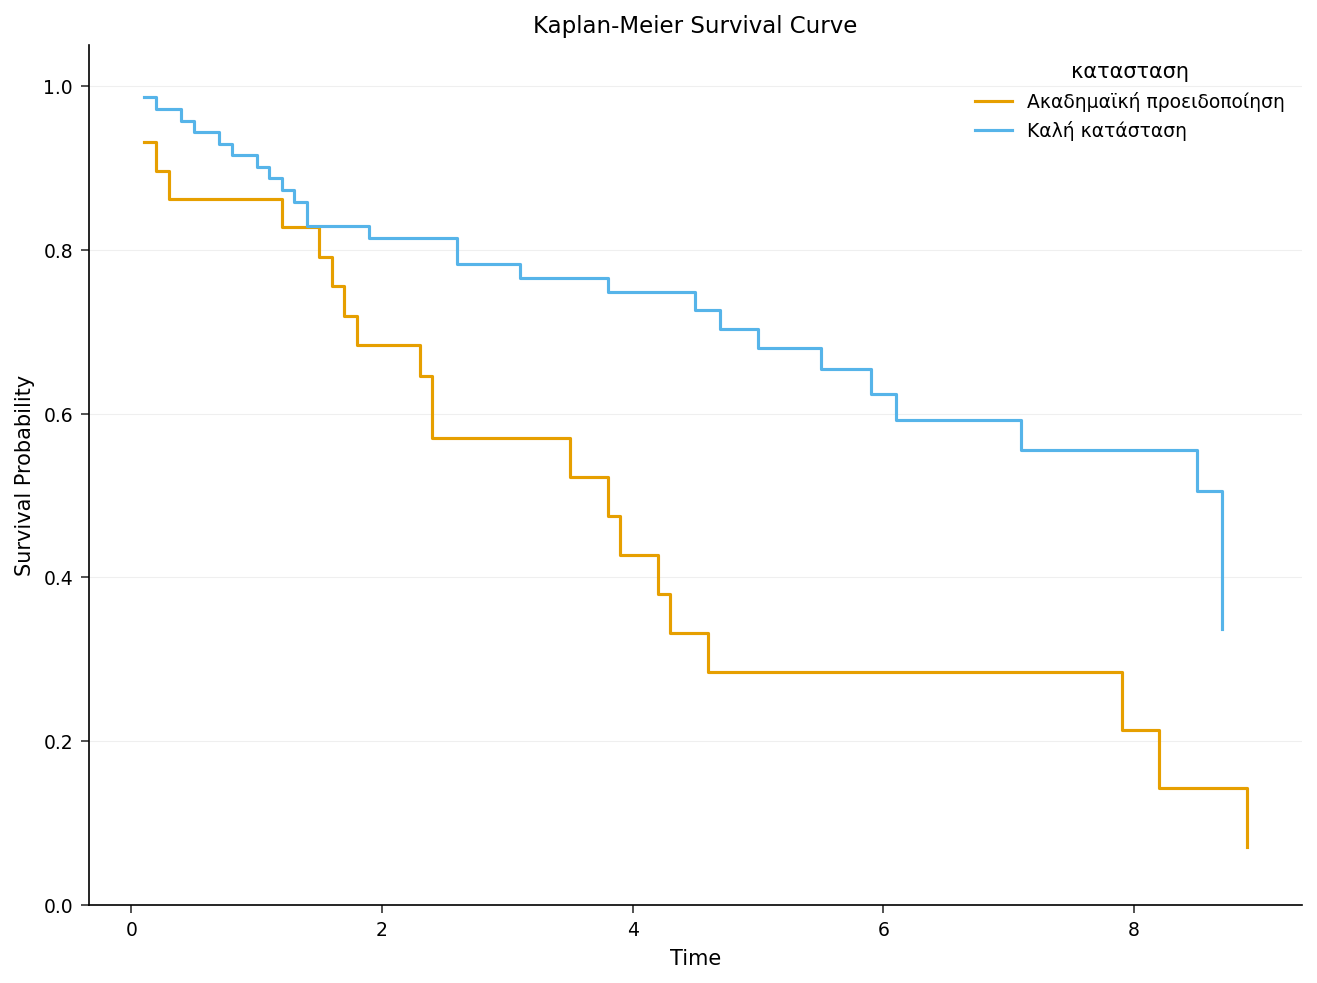

In [5]:
ΔΙΑΔΙΚΑΣΙΑ LIFETEST ΔΕΔΟΜΕΝΑ=εγγραφες PLOTS=SURVIVAL METHOD=km;
    TIME χρονος_εξαμηνα*εγκατελειψε(0);
    STRATA κατασταση / TEST=(logrank WILCOXON);
ΕΚΤΕΛΕΣΗ;

## 6. Πολυμεταβλητό μοντέλο αναλογικών κινδύνων Cox για την εγκατάλειψη

Η **PROC PHREG** προσαρμόζει το μοντέλο **αναλογικών κινδύνων Cox** για τον κίνδυνο εγκατάλειψης, προσαρμόζοντας τους προβλέπτες ταυτόχρονα. Βασικά αιτήματα:

- Το `εγκατελειψε(0)` καθιστά την **εγκατάλειψη** το συμβάν και όλα τα υπόλοιπα λογοκριμένα.
- Το `CLASS ετικετα_γενιας (ref="Συνεχιζόμενης γενιάς") / param=ref` κωδικοποιεί ως προς αναφορά τον παράγοντα πρώτης γενιάς ώστε ο λόγος κινδύνου του να διαβάζεται έναντι των φοιτητών συνεχιζόμενης γενιάς.
- Το `TIES=EFRON` είναι η συνιστώμενη προσέγγιση χειρισμού ισοπαλιών όταν αρκετοί φοιτητές αποχωρούν στο ίδιο εξάμηνο.
- Το `RL` προσθέτει διαστήματα εμπιστοσύνης λόγου κινδύνου (ορίων κινδύνου).
- Η δήλωση `HAZARDRATIO` αναφέρει την αντιπαραβολή πρώτης γενιάς έναντι της ομάδας αναφοράς.

Ένας λόγος κινδύνου πάνω από 1 σημαίνει *ταχύτερη* εγκατάλειψη (υψηλότερος κίνδυνος)· κάτω από 1 σημαίνει *βραδύτερη* εγκατάλειψη (προστατευτικός).

In [6]:
ΔΙΑΔΙΚΑΣΙΑ PHREG ΔΕΔΟΜΕΝΑ=εγγραφες;
    ΚΛΑΣΗ ετικετα_γενιας (REF="Συνεχιζόμενης γενιάς") / PARAM=REF;
    ΜΟΝΤΕΛΟ χρονος_εξαμηνα*εγκατελειψε(0) = gpa_λυκειου gpa_α_εξαμηνου ετικετα_γενιας pell
          / TIES=efron rl;
    hazardratio "Πρώτης γενιάς έναντι συνεχιζόμενης" ετικετα_γενιας / DIFF=REF;
ΕΚΤΕΛΕΣΗ;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     31.1053         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.2100         4      <.0001

                                                         Analysis of Maximum Likelihood Estimates                                                          

Parameter                                                    DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
-----------------------------------------------------  --------  --------  --------------


NOTE: PROC PHREG data=εγγραφες

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. Ερμηνεία και επόμενα βήματα

**Ανάγνωση της εξόδου, από άκρη σε άκρη:**

- Η **PROC MEANS** επιβεβαιώνει το προσομοιωμένο σήμα: οι φοιτητές που αποφοίτησαν φέρουν υψηλότερο GPA πρώτου εξαμήνου (2.94 έναντι 2.54) και GPA λυκείου (3.10 έναντι 2.90) από τους φοιτητές που εγκατέλειψαν, και οι ακόμη εγγεγραμμένοι φοιτητές βρίσκονται στην οροφή των 12 εξαμήνων — τη δεξιά λογοκρισία που σέβονται τα μοντέλα επιβίωσης.
- Η **PROC FREQ** δείχνει ότι η σημαία ακαδημαϊκής προειδοποίησης πρώτου εξαμήνου παρακολουθεί το αποτέλεσμα (21 από 29 επισημασμένους φοιτητές εγκατέλειψαν· 41 από 71 φοιτητές καλής κατάστασης αποφοίτησαν· *p* = 0.0100), ενώ επισημαίνει ειλικρινά ότι το χι-τετράγωνο είναι εύθραυστο σε έναν πίνακα 100 φοιτητών με αραιά κελιά.
- Η **PROC UNIVARIATE** δείχνει ότι *υπό την προϋπόθεση εγκατάλειψης*, και οι δύο ομάδες αποχωρούν νωρίς (διάμεσος ~2.4–2.6 εξάμηνα)· η επίδραση της κατάστασης αφορά το πόσοι φοιτητές εγκαταλείπουν και πόσο γρήγορα αραιώνει η δεξαμενή κινδύνου, όχι τον χρονισμό μεταξύ όσων αποχωρούν.
- Η **PROC LIFETEST** παραδίδει τον τίτλο: καμπύλες εγκατάλειψης Kaplan-Meier που διαχωρίζονται έντονα κατά κατάσταση (διάμεσος 3.8 έναντι 8.7 εξάμηνα· log-rank *p* = 0.0011, Wilcoxon *p* = 0.0056). Η σημαία έγκαιρης προειδοποίησης είναι ένας γνήσιος, στατιστικά υποστηριζόμενος διαχωριστής του χρονισμού εγκατάλειψης.
- Η **PROC PHREG** ποσοτικοποιεί την προσαρμοσμένη επίδραση κάθε προβλέπτη στον κίνδυνο εγκατάλειψης. Μετά την προσαρμογή, το **GPA πρώτου εξαμήνου είναι ο ισχυρότερος προστατευτικός παράγοντας** (λόγος κινδύνου 0.21 ανά μονάδα GPA, 95% CI 0.10–0.44, *p* < 0.0001): κάθε επιπλέον μονάδα GPA μειώνει τον κίνδυνο εγκατάλειψης κατά περίπου τέσσερα πέμπτα. Το **GPA λυκείου** είναι επίσης προστατευτικό (HR 0.45, 95% CI 0.22–0.91, *p* = 0.027). Οι **φοιτητές πρώτης γενιάς** αντιμετωπίζουν περίπου διπλάσιο κίνδυνο εγκατάλειψης από τους συνομηλίκους συνεχιζόμενης γενιάς με τα ίδια GPA (HR 2.03, 95% CI 1.07–3.84, *p* = 0.031). Η **κατάσταση Pell δεν είναι σημαντική** όταν ελέγχεται το GPA (HR 0.95, 95% CI 0.53–1.69, *p* = 0.85) — μια χρήσιμη υπενθύμιση ότι ένας ακατέργαστος παράγοντας κινδύνου μπορεί να εξαλειφθεί μετά την προσαρμογή. Η καθολική μηδενική υπόθεση απορρίπτεται αποφασιστικά (χι-τετράγωνο λόγου πιθανοφάνειας = 31.11 σε 4 df, *p* < 0.0001).

**Πώς θα ενεργούσε ένα ίδρυμα με βάση αυτό.** Το μοντέλο Cox παράγει έναν γραμμικό προβλέπτη ανά φοιτητή (βαθμολογία κινδύνου) που κατατάσσει την κοόρτη κατά κίνδυνο εγκατάλειψης· οι φοιτητές υψηλότερου κινδύνου — χαμηλό GPA πρώτου εξαμήνου σε συνδυασμό με κατάσταση πρώτης γενιάς — δρομολογούνται σε συμβουλευτική έγκαιρης προειδοποίησης στα πρώτα τους εξάμηνα, όταν η παρέμβαση είναι φθηνότερη και πιο αποτελεσματική. Η σύγκριση Kaplan-Meier δίνει στους συμβούλους ένα μοναδικό, υπερασπίσιμο κριτήριο που ήδη συλλέγουν στο τέλος του πρώτου εξαμήνου: την ακαδημαϊκή κατάσταση.

**Επιφυλάξεις και επεκτάσεις.** (1) Αυτή η συνθετική κοόρτη αντιμετωπίζει την αποφοίτηση ως λογοκρισία για το μοντέλο εγκατάλειψης· με πραγματικά δεδομένα, η αποφοίτηση και η εγκατάλειψη είναι γνήσιοι **ανταγωνιστικοί κίνδυνοι**, και μια επέκταση ανταγωνιστικών κινδύνων (αθροιστικής επίπτωσης) μέσω του `EVENTCODE=` της PROC PHREG θα απέφευγε την υπερεκτίμηση της πιθανότητας εγκατάλειψης. (2) Η υπόθεση αναλογικών κινδύνων θα πρέπει να ελεγχθεί (PHREG `ASSESS PH` ή υπόλοιπα Schoenfeld) πριν εμπιστευτεί κανείς έναν μοναδικό λόγο κινδύνου σε όλα τα εξάμηνα. (3) Οι χρονικά μεταβαλλόμενες συμμεταβλητές — GPA ανά εξάμηνο, αλλαγές οικονομικής ενίσχυσης, φόρτος μαθημάτων — είναι συνήθεις σε δεδομένα διατήρησης και χειρίζονται φυσικά από δηλώσεις προγραμματισμού της PHREG. (4) Η κοόρτη 100 φοιτητών εδώ έχει μέγεθος προσαρμοσμένο στο όριο εκτέλεσης χωρίς άδεια· μια παραγωγική ανάλυση θα έφερε αρκετές χιλιάδες φοιτητές, στενεύοντας κάθε διάστημα εμπιστοσύνης. Πάντα να επικυρώνετε μια αναπτυγμένη βαθμολογία κινδύνου σε μια κοόρτη εκτός δείγματος πριν ενεργήσετε με βάση αυτή επιχειρησιακά.